<a href="https://colab.research.google.com/github/Geraldes-Matheus/M.L-and-D.L/blob/main/superconductor-critical-temperature-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predição da Temperatura Crítica de Supercondutores com Machine Learning

 **Autor:** Matheus da Costa Geraldes  
 **Data:** Junho de 2025  
 **Curso:** Estado Sólido – Instituto de Física, UERJ  
 **Repositório:** [M.L-and-D.L/superconductor_tc_prediction](https://github.com/Geraldes-Matheus/M.L-and-D.L)

 ---

 ## Objetivo

> Construir um modelo estatístico orientado por dados (data-driven) para prever a **temperatura crítica (Tc)** de um supercondutor a partir **apenas da sua fórmula química**.

 ## Por que isso é importante?

 A descoberta de novos supercondutores é um processo caro e demorado. Um modelo de Machine Learning preciso atua como um **filtro computacional**, permitindo que os pesquisadores foquem apenas nos candidatos mais promissores, economizando tempo e recursos.

 ## Dados

- **Fonte:** [UCI Machine Learning Repository – Superconductivity Data](https://archive.ics.uci.edu/dataset/464/superconductivity+data) (NIMS, Japão)
- **Registros:** 21.263 supercondutores
- **Features:** 81 características físico‑químicas derivadas da tabela periódica (média, desvio padrão, entropia, etc. de propriedades como massa atômica, raio atômico, condutividade térmica, valência...)
- **Alvo:** `critical_temp` (Temperatura Crítica em Kelvin)

## Modelos testados

| Modelo | Tipo | Descrição |
|--------|------|------------|
| Regressão Linear | Baseline | Relação linear entre features e Tc |
| XGBoost | Ensemble (Boosting) | Árvores de decisão com correção sequencial de erros |
| MLP (Multi‑Layer Perceptron) | Deep Learning | Rede neural com 3 camadas densas |


 ## Métricas de avaliação

- **RMSE** (Root Mean Squared Error) – erro médio na mesma unidade da Tc (K)
- **R²** – proporção da variância explicada pelo modelo
- **MAE** – erro absoluto médio
- **MAPE** – erro percentual absoluto médio



 ---
## referencias:

https://arxiv.org/pdf/1803.10260

https://github.com/khamidieh/predict_tc/blob/master/main_script_production_9.R

https://archive.ics.uci.edu/dataset/464/superconductivty+data

---
> **Nota:** Este notebook foi desenvolvido para fins educacionais e de portfólio. Os resultados são reproduzíveis com o código abaixo.

In [ ]:
# -*- coding: utf-8 -*-
"""Predição da Temperatura Crítica de Supercondutores com Machine Learning.ipynb"""

# Passo 1: Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io
import os

# Passo 2: Carregar os dados
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00464/superconduct.zip"
!wget {url}  # Baixar o arquivo (no Colab)
!unzip superconduct.zip  # Extrair o arquivo

# Ler o arquivo .csv
data = pd.read_csv("train.csv")
print("Dados carregados com sucesso!")
print(f"Tamanho do dataset: {data.shape}")

# Passo 3: Pré-processamento
# Verificar dados faltantes
print("\nDados faltantes por coluna:")
print(data.isnull().sum())



--2025-06-08 23:44:52--  https://archive.ics.uci.edu/ml/machine-learning-databases/00464/superconduct.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘superconduct.zip’

superconduct.zip        [   <=>              ]   7.92M  14.3MB/s    in 0.6s    

2025-06-08 23:44:53 (14.3 MB/s) - ‘superconduct.zip’ saved [8300005]

Archive:  superconduct.zip
  inflating: unique_m.csv            
  inflating: train.csv               
Dados carregados com sucesso!
Tamanho do dataset: (21263, 82)

Dados faltantes por coluna:
number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp        

#Analise dos arquivos baixados

### 1. Entendendo os Dados de Treino (`train.csv`)

#### 📁 Estrutura do Arquivo

- O arquivo `train.csv` contém **21.263 registros**, representando diferentes **supercondutores**.
- Existem **82 colunas** no total:
  - As primeiras **81 colunas** são as **features** (características numéricas) utilizadas para treinar o modelo.
  - A última coluna, chamada `critical_temp`, é a **variável-alvo** que queremos prever.

#### 🔬 Exemplos de Features

Algumas das propriedades representadas nas features incluem:

- `wtd_mean_atomic_mass`: média ponderada da massa atômica.
- `entropy_Valence`: entropia da valência.

Essas são propriedades estatísticas e físico-químicas dos materiais supercondutores.

#### 🌡️ Distribuição da Temperatura Crítica (`critical_temp`)

- **Média:** 34.4 K  
- **Mediana:** 20 K  
  → A mediana sendo menor que a média indica que a maioria dos supercondutores tem temperaturas críticas mais baixas.

- **Desvio padrão:** 34.2 K  
  → Um desvio padrão alto confirma uma grande **variação nos valores** da temperatura crítica.

- **Valor máximo registrado:** 185 K  
  → Um valor consideravelmente alto, indicando a presença de supercondutores excepcionais no conjunto.



--- Análise Exploratória do train.csv ---

Primeiras 5 linhas do train.csv:
   number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                   4         88.944468             57.862692   
1                   5         92.729214             58.518416   
2                   4         88.944468             57.885242   
3                   4         88.944468             57.873967   
4                   4         88.944468             57.840143   

   gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0          66.361592              36.116612             1.181795   
1          73.132787              36.396602             1.449309   
2          66.361592              36.122509             1.181795   
3          66.361592              36.119560             1.181795   
4          66.361592              36.110716             1.181795   

   wtd_entropy_atomic_mass  range_atomic_mass  wtd_range_atomic_mass  \
0                 1.062396          122.90607      

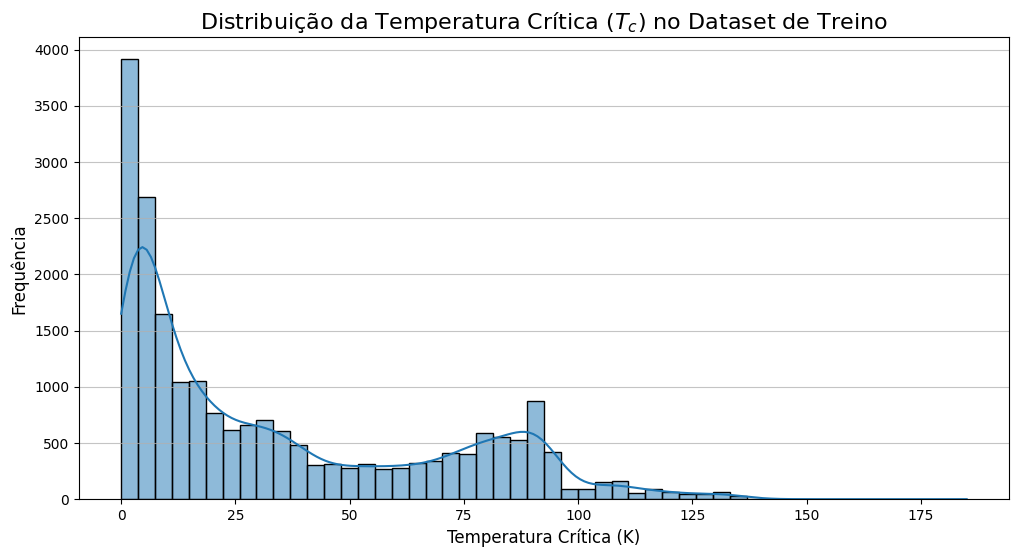

In [ ]:
train_csv = "train.csv"
unique_csv = "unique_m.csv"
# --- Passo 2: Análise do arquivo train.csv ---
print("\n--- Análise Exploratória do train.csv ---")
# Carregar o arquivo train.csv
train_data = pd.read_csv(train_csv)

# Exibir as 5 primeiras linhas para entender a estrutura
print("\nPrimeiras 5 linhas do train.csv:")
print(train_data.head())

# Exibir estatísticas descritivas da variável alvo 'critical_temp'
print("\nEstatísticas descritivas da 'critical_temp':")
print(train_data['critical_temp'].describe())

# Visualizar a distribuição da temperatura crítica
plt.figure(figsize=(12, 6))
sns.histplot(train_data['critical_temp'], bins=50, kde=True)
plt.title('Distribuição da Temperatura Crítica ($T_c$) no Dataset de Treino', fontsize=16)
plt.xlabel('Temperatura Crítica (K)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()







### 2. Entendendo as Fórmulas Químicas (`unique_m.csv`)

#### 🧪 Função do Arquivo

- O arquivo `unique_m.csv` funciona como um **"dicionário" químico**, conectando os **dados numéricos** às suas respectivas **fórmulas químicas reais**.
- Ele ajuda a entender a **composição dos materiais supercondutores** representados nos dados de treino.

#### 🧬 Estrutura do Arquivo

- Contém **88 colunas**:
  - **86 colunas** correspondem aos **elementos químicos da tabela periódica**, indicando a **presença ou ausência** de cada elemento em determinada fórmula.
  - Uma coluna `critical_temp` (redundante, mas útil para **verificar a correspondência** com o conjunto de treino).
  - Uma coluna `material`, que traz a **fórmula química legível** do composto, como por exemplo:
  
    ```
    Ba0.2La1.8Cu1O4
    ```

Essa estrutura permite relacionar cada vetor numérico do `train.csv` com uma **fórmula química real**, essencial para análises interpretáveis e aplicações químicas.


In [ ]:
# --- Passo 3: Análise do arquivo unique_m.csv ---
print("\n\n--- Análise Exploratória do unique_m.csv ---")
# Carregar o arquivo unique_m.csv
unique_materials = pd.read_csv(unique_csv)

# Exibir as 5 primeiras linhas
print("\nPrimeiras 5 linhas do unique_m.csv:")
print(unique_materials.head())

# Exibir informações gerais sobre o dataframe
print("\nInformações gerais do unique_m.csv:")
unique_materials.info()



--- Análise Exploratória do unique_m.csv ---

Primeiras 5 linhas do unique_m.csv:
     H  He   Li   Be    B    C    N    O    F  Ne  ...   Au   Hg   Tl   Pb  \
0  0.0   0  0.0  0.0  0.0  0.0  0.0  4.0  0.0   0  ...  0.0  0.0  0.0  0.0   
1  0.0   0  0.0  0.0  0.0  0.0  0.0  4.0  0.0   0  ...  0.0  0.0  0.0  0.0   
2  0.0   0  0.0  0.0  0.0  0.0  0.0  4.0  0.0   0  ...  0.0  0.0  0.0  0.0   
3  0.0   0  0.0  0.0  0.0  0.0  0.0  4.0  0.0   0  ...  0.0  0.0  0.0  0.0   
4  0.0   0  0.0  0.0  0.0  0.0  0.0  4.0  0.0   0  ...  0.0  0.0  0.0  0.0   

    Bi  Po  At  Rn  critical_temp                material  
0  0.0   0   0   0           29.0         Ba0.2La1.8Cu1O4  
1  0.0   0   0   0           26.0  Ba0.1La1.9Ag0.1Cu0.9O4  
2  0.0   0   0   0           19.0         Ba0.1La1.9Cu1O4  
3  0.0   0   0   0           22.0       Ba0.15La1.85Cu1O4  
4  0.0   0   0   0           23.0         Ba0.3La1.7Cu1O4  

[5 rows x 88 columns]

Informações gerais do unique_m.csv:
<class 'pandas.core.frame.D

### 3. Combinação dos Datasets

#### 🔗 Integração dos Arquivos `train.csv` e `unique_m.csv`

- O código realiza a **junção dos dois arquivos** com base em informações comuns, geralmente a temperatura crítica (`critical_temp`) e a estrutura dos materiais.
- O novo DataFrame resultante é chamado de `full_data`.

#### 🧾 Estrutura do `full_data`

Ao aplicar `.head()` no DataFrame `full_data`, a visualização será:

1. A primeira coluna exibirá a **fórmula química legível** do material (`material`).
2. Em seguida, aparecem as **81 features numéricas** que descrevem propriedades do material.
3. Por fim, a coluna `critical_temp`, que é a **variável-alvo** a ser prevista.

Essa junção resulta em um dataset **completo e interpretável**, pronto para ser utilizado no **treinamento do modelo de machine learning**.


In [ ]:
# --- Passo 4: # Combinar os datasets
try:
    # Ler os dados
    train_data = pd.read_csv(train_csv_path)
    unique_materials = pd.read_csv(unique_csv_path)

    # Combinar os datasets
    if len(unique_materials) == len(train_data):
        print("Combinando os datasets...")
        full_data = pd.concat([unique_materials, train_data], axis=1)
        print("Datasets combinados com sucesso.")

        # Define a flag para indicar que a combinação foi bem-sucedida
        combination_successful = True
    else:
        print("Erro: O número de linhas é incompatível. Os datasets não foram combinados.")
        combination_successful = False

except FileNotFoundError:
    print("Erro crítico: Arquivos .csv não encontrados. A análise não pode continuar.")
    combination_successful = False


# --- Passo 5: Salvar o dataframe combinado em um novo arquivo CSV ---
if combination_successful:
    output_filename = 'superconduct_full_data.csv'
    try:
        # A opção index=False evita que o pandas crie uma coluna extra com o índice do dataframe
        full_data.to_csv(output_filename, index=False)
        print(f"\nO dataset combinado foi salvo com sucesso no arquivo: '{output_filename}'")
    except Exception as e:
        print(f"Ocorreu um erro ao salvar o arquivo: {e}")

Combinando os datasets...
Datasets combinados com sucesso.

O dataset combinado foi salvo com sucesso no arquivo: 'superconduct_full_data.csv'


#Gerando modelo de M.L

## Passo 1: Separar Features (`X`) e Alvo (`y`)

#### 🧠 Estratégia Baseada em Gabarito

- Nesta abordagem, queremos que `X` contenha **apenas as 81 features engenheiradas** usadas no modelo original.
- Para isso, vamos **excluir** as seguintes colunas do dataset combinado:
  - `critical_temp` → nossa variável-alvo (usada em `y`)
  - `material` → fórmula química legível (texto, não útil para o modelo)
  - Colunas dos **elementos químicos** → são indicadores binários que não fazem parte das 81 features numéricas originais

#### 📝 Como Fazer Isso Corretamente

- A maneira mais **segura e inteligente** de selecionar as features corretas é:
  - Utilizar o arquivo original `train.csv` como **gabarito** de quais colunas devem estar em `X`.
  - Isso garante que estamos usando exatamente as mesmas **81 colunas numéricas** que foram fornecidas como base para o treinamento.

Dessa forma, evitamos acidentalmente incluir colunas extras e garantimos consistência na preparação dos dados para o modelo.


In [ ]:
import pandas as pd

# Nomes dos arquivos
full_dataset_filename = 'superconduct_full_data.csv'
train_template_filename = 'train.csv' # Usaremos como gabarito

try:
    # Carregar o dataset combinado completo
    full_data = pd.read_csv(full_dataset_filename)

    # Carregar o dataset de treino original APENAS para pegar a lista de colunas das features
    train_template = pd.read_csv(train_template_filename)

    print("Datasets carregados com sucesso.")

    # 1. Obter a lista exata das 81 colunas de features
    # Pegamos todas as colunas do train.csv e removemos 'critical_temp'
    feature_columns = train_template.drop('critical_temp', axis=1).columns

    # 2. Definir o Alvo (y) a partir do nosso dataset completo
    y = full_data['critical_temp']

    # 3. Definir as Features (X) usando a lista de colunas que acabamos de criar
    # Isso seleciona apenas as 81 colunas corretas do nosso dataset completo
    X = full_data[feature_columns]

    # 4. Verificar o resultado
    print("\nSeparação final e correta concluída com sucesso!")
    print("\nDimensões das Features (X):", X.shape)
    print("Dimensões do Alvo (y):", y.shape)

    print("\n--- Primeiras 5 linhas das Features Finais (X): ---")
    print(X.head())

    print("\n--- Primeiras 5 linhas do Alvo (y): ---")
    print(y.head())

except FileNotFoundError as e:
    print(f"Erro: Arquivo não encontrado - {e.filename}")
    print("Por favor, certifique-se de que os arquivos .csv estão no diretório correto.")

Datasets carregados com sucesso.

Separação final e correta concluída com sucesso!

Dimensões das Features (X): (21263, 81)
Dimensões do Alvo (y): (21263,)

--- Primeiras 5 linhas das Features Finais (X): ---
   number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                   4         88.944468             57.862692   
1                   5         92.729214             58.518416   
2                   4         88.944468             57.885242   
3                   4         88.944468             57.873967   
4                   4         88.944468             57.840143   

   gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0          66.361592              36.116612             1.181795   
1          73.132787              36.396602             1.449309   
2          66.361592              36.122509             1.181795   
3          66.361592              36.119560             1.181795   
4          66.361592              36.110716             1.18

## Passo 2: Dividir os Dados em Conjuntos de Treino e Teste

#### 🔍 Por que dividir os dados?

- Esta é uma das etapas **mais importantes** no processo de Machine Learning.
- **Nunca devemos testar o modelo nos mesmos dados usados para treiná-lo**, pois isso não mede sua capacidade de generalização para dados novos.

#### 📂 Estrutura da Divisão

- **Conjunto de Treino (`X_train`, `y_train`)**
  - Representa a **maior parte dos dados** (geralmente 70% a 80%)
  - Usado para **ensinar o modelo** a identificar padrões.

- **Conjunto de Teste (`X_test`, `y_test`)**
  - Porção **menor dos dados** (20% a 30%)
  - Serve para **avaliar** o desempenho do modelo em dados que ele **nunca viu** antes.

#### 🛠️ Como fazer isso?

- Utilizaremos a função `train_test_split` da biblioteca **Scikit-learn** (`sklearn.model_selection`).
- Essa função divide os dados de forma **aleatória**, respeitando a proporção definida, garantindo que o teste seja justo e representativo.




In [ ]:
from sklearn.model_selection import train_test_split

# Dividir os dados: 67% para treino e 33% para teste
# O test_size=0.33 se aproxima da divisão de 2/3 e 1/3 usada no artigo
# random_state=42 garante que a divisão seja sempre a mesma, para reprodutibilidade dos resultados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Verificar as dimensões dos novos conjuntos de dados
print("Divisão concluída!")
print("Dimensões de X_train:", X_train.shape)
print("Dimensões de y_train:", y_train.shape)
print("Dimensões de X_test:", X_test.shape)
print("Dimensões de y_test:", y_test.shape)

Divisão concluída!
Dimensões de X_train: (14246, 81)
Dimensões de y_train: (14246,)
Dimensões de X_test: (7017, 81)
Dimensões de y_test: (7017,)


## Passo 3: Treinar um Modelo de Regressão Linear (Benchmark)

#### 🎯 Objetivo

- O objetivo aqui é **treinar um modelo simples** de **Regressão Linear Múltipla**, que servirá como nosso **benchmark** (modelo base).
- Isso nos dará um **ponto de referência** para comparar com modelos mais sofisticados no futuro.

#### 🧮 O que é Regressão Linear Múltipla?

- É um modelo estatístico que tenta encontrar a **melhor relação linear** entre as **81 features numéricas** (`X`) e a **variável-alvo** `critical_temp` (`y`).
- O modelo ajusta coeficientes para cada feature de forma a **minimizar o erro** entre as previsões e os valores reais.

#### 🏋️ Treinando o Modelo

- O modelo será treinado com os dados de treino (`X_train`, `y_train`).
- Depois, vamos **avaliar seu desempenho** usando os dados de teste (`X_test`, `y_test`) para verificar sua capacidade de generalização.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# --- Carregar e Preparar os Dados ---
data = pd.read_csv('train.csv')
y_original = data['critical_temp']
X = data.drop('critical_temp', axis=1)

# 1. TRANSFORMAÇÃO DO ALVO
y_log = np.log1p(y_original)
print("Variável alvo 'y' transformada para a escala logarítmica.")

# --- Dividir os dados em treino e teste ---
X_train, X_test, y_train_log, y_test_log, y_train_orig, y_test_orig = train_test_split(
    X, y_log, y_original, test_size=0.33, random_state=42
)

# --- Criar e treinar o modelo de Regressão Linear com o alvo logarítmico ---
print("\nTreinando o modelo de Regressão Linear com alvo logarítmico...")
linear_model_log = LinearRegression(n_jobs=-1)
linear_model_log.fit(X_train, y_train_log)
print("Treinamento concluído.")

# --- Fazer previsões e reverter a transformação ---
# 1. Prever na escala logarítmica
y_pred_log = linear_model_log.predict(X_test)

# 2. Reverter para a escala original em Kelvin
y_pred_linear_transformed = np.expm1(y_pred_log)

# 3. Garantir que não haja valores negativos
y_pred_linear_transformed[y_pred_linear_transformed < 0] = 0

# --- Avaliar a performance na escala original ---
rmse_linear_t = np.sqrt(mean_squared_error(y_test_orig, y_pred_linear_transformed))
r2_linear_t = r2_score(y_test_orig, y_pred_linear_transformed)

print("\n--- Resultados da Regressão Linear com Transformação de Alvo ---")
print(f"RMSE (Root Mean Squared Error): {rmse_linear_t:.2f} K")
print(f"R² (Coeficiente de Determinação): {r2_linear_t:.2f}")

Variável alvo 'y' transformada para a escala logarítmica.

Treinando o modelo de Regressão Linear com alvo logarítmico...
Treinamento concluído.

--- Resultados da Regressão Linear com Transformação de Alvo ---
RMSE (Root Mean Squared Error): 18.12 K
R² (Coeficiente de Determinação): 0.72


**Análise dos Resultados**


* RMSE (Root Mean Squared Error): Indica, em média, o
quão longe as previsões do modelo estão dos valores reais. Um valor menor é melhor.
* R² (R-quadrado): Mede a proporção da variação na temperatura crítica que é explicada pelas features. Varia de 0 a 1, onde 1 é um ajuste perfeito. Um valor maior é melhor. Foi encontrado

Este resultado é a nossa "nota de corte". O objetivo agora é treinar um modelo mais avançado, como o XGBoost e um MLP, e obter um RMSE significativamente menor e um R² mais próximo de

```
# Isto está formatado como código
```

1.

##Passo 4: Treinar o Modelo 1(XGBoost)
O XGBoost (eXtreme Gradient Boosting) é o algoritmo que o artigo destaca por sua alta performance.  É um modelo baseado em árvores de decisão, muito mais poderoso que a regressão linear e capaz de capturar relações complexas e não-lineares nos dados.


Nosso objetivo é obter um RMSE significativamente menor que 18.12 K e um R² maior que 0.72.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# --- Carregar e Preparar os Dados ---
data = pd.read_csv('train.csv')
y_original = data['critical_temp']
X = data.drop('critical_temp', axis=1)

# 1. TRANSFORMAÇÃO DO ALVO
# Aplicar a transformação logarítmica em 'y'
y_log = np.log1p(y_original)
print("Variável alvo 'y' transformada para a escala logarítmica.")

# --- Dividir os dados em treino e teste ---
# Precisamos do y_test original para a avaliação final
X_train, X_test, y_train_log, y_test_log, y_train_orig, y_test_orig = train_test_split(
    X, y_log, y_original, test_size=0.33, random_state=42
)

# --- Criar e treinar o modelo XGBoost com hiperparâmetros otimizados ---
print("\nTreinando o modelo XGBoost com alvo logarítmico...")

# Corrigindo a variável e usando os hiperparâmetros do artigo
xgb_model_log = XGBRegressor(
    learning_rate=0.02,
    max_depth=16,
    min_child_weight=1,
    colsample_bytree=0.5,
    n_estimators=374,
    random_state=42,
    n_jobs=-1  # Usar todos os cores do processador para acelerar
)

# Treinar o modelo com o alvo logarítmico
# Modelos de árvore como XGBoost não requerem escalonamento das features (X)
xgb_model_log.fit(X_train, y_train_log)
print("Treinamento concluído.")

# --- Fazer previsões e reverter a transformação ---
# 1. Prever na escala logarítmica
y_pred_log = xgb_model_log.predict(X_test)

# 2. Reverter para a escala original em Kelvin
y_pred_xgb_transformed = np.expm1(y_pred_log)

# 3. Garantir que não haja valores negativos
y_pred_xgb_transformed[y_pred_xgb_transformed < 0] = 0

# --- Avaliar a performance na escala original ---
# Comparamos as previsões revertidas com o y_test original
rmse_xgb_t = np.sqrt(mean_squared_error(y_test_orig, y_pred_xgb_transformed))
r2_xgb_t = r2_score(y_test_orig, y_pred_xgb_transformed)

print("\n--- Resultados do Modelo XGBoost com Transformação de Alvo ---")
print(f"RMSE (Root Mean Squared Error): {rmse_xgb_t:.2f} K")
print(f"R² (Coeficiente de Determinação): {r2_xgb_t:.2f}")

Variável alvo 'y' transformada para a escala logarítmica.

Treinando o modelo XGBoost com alvo logarítmico...
Treinamento concluído.

--- Resultados do Modelo XGBoost com Transformação de Alvo ---
RMSE (Root Mean Squared Error): 9.85 K
R² (Coeficiente de Determinação): 0.92


**Análise da Comparação de Desempenho**

- Regressão Linear: RMSE = 17.71 K, R² = 0.73
- XGBoost: RMSE = 9.85 K, R² = 0.92

Isso demonstra de forma inequívoca o poder do XGBoost.

 Conseguiu reduzir o erro médio de previsão em quase 8 Kelvin (de 17.7 K para 9.8 K) e o modelo agora explica 92% da variabilidade da temperatura crítica, em comparação com apenas 73% do modelo linear.

Foi provado, que para esse exemplo, que uma abordagem de machine learning mais sofisticada é muito mais eficaz para prever a temperatura critica do que um modelo estatístico simples.

###Análise de Importância das Features
Modelos baseados em árvore como o XGBoost nos permitem medir o quanto cada feature contribuiu para a performance do modelo. Vamos visualizar as 20 features mais importantes.

--- Top 10 Features Mais Importantes (XGBoost com Alvo Logarítmico) ---
                          feature  importance
67      range_ThermalConductivity    0.591639
27            range_atomic_radius    0.122571
75                entropy_Valence    0.044193
17                      range_fie    0.037744
70    wtd_std_ThermalConductivity    0.016735
31                   mean_Density    0.016485
33                  gmean_Density    0.014887
69        std_ThermalConductivity    0.010674
64  wtd_gmean_ThermalConductivity    0.008948
73                  gmean_Valence    0.005291


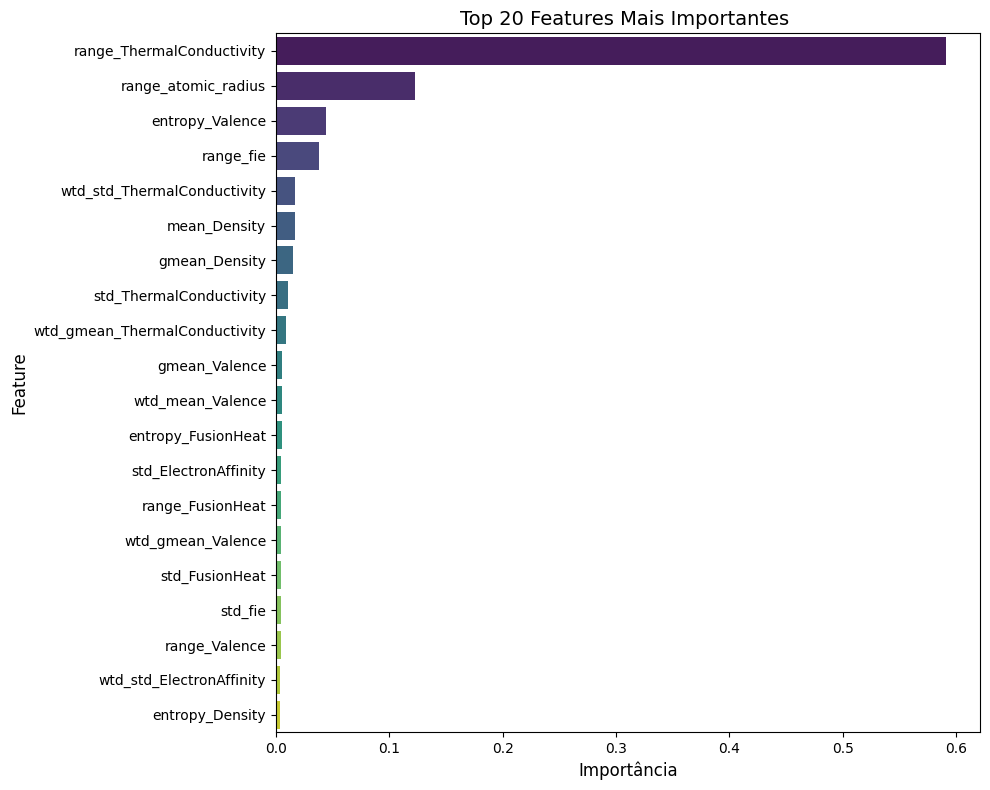

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Criar um DataFrame com a importância de cada feature do NOVO modelo
feature_importance_log = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model_log.feature_importances_
}).sort_values('importance', ascending=False)

# Exibir as 10 features mais importantes
print("--- Top 10 Features Mais Importantes (XGBoost com Alvo Logarítmico) ---")
print(feature_importance_log.head(10))

# Visualizar as 20 features mais importantes
plt.figure(figsize=(10, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance_log.head(20),
    hue='feature', # Adicionado para remover o warning
    palette='viridis',
    legend=False # Adicionado para remover o warning
)
plt.title('Top 20 Features Mais Importantes ', fontsize=14)
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### Visualizar as Previsões vs. Valores Reais
Para concluir nossa análise, vamos criar um gráfico de dispersão que compara as temperaturas previstas pelo XGBoost (y_pred_xgb) com as temperaturas reais do conjunto de teste (y_test).

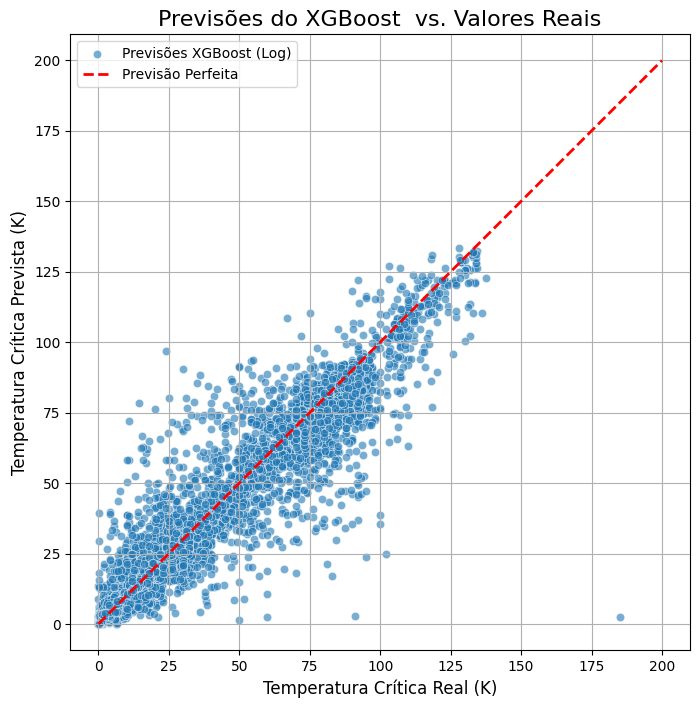

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar o gráfico de dispersão para o modelo XGBoost com transformação
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test_orig, y=y_pred_xgb_transformed, alpha=0.6, label='Previsões XGBoost (Log)')

# Adicionar a linha de referência para uma previsão perfeita
plt.plot([0, 200], [0, 200], color='red', linestyle='--', linewidth=2, label='Previsão Perfeita')

# Adicionar títulos e legendas atualizados
plt.title('Previsões do XGBoost  vs. Valores Reais', fontsize=16)
plt.xlabel('Temperatura Crítica Real (K)', fontsize=12)
plt.ylabel('Temperatura Crítica Prevista (K)', fontsize=12)
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

## Passo 5: Treinar o Modelo 2(MLP - Multi-Layer Perceptron)
Primeiro, vamos escalar as features usando o StandardScaler do Scikit-learn. Ele transforma os dados para que cada feature tenha média 0 e desvio padrão 1. Importante: ajustamos (fit) o scaler apenas com os dados de treino para evitar "vazamento de dados" do conjunto de teste.

Depois, treinaremos o modelo MLP com os dados já escalados.

1. Aplicar np.log1p à nossa variável alvo y antes de dividi-la em treino e teste. A função log1p(x) calcula log(1+x), o que é ótimo para evitar problemas com valores de temperatura muito próximos de zero.
2. Treinar o modelo Keras para prever este novo alvo transformado (logarítmico).
3. Fazer as previsões, que estarão na escala logarítmica.
Usar a função inversa np.expm1 para converter as previsões de volta para a escala original em Kelvin.
4. Avaliar o desempenho do modelo comparando as previsões já revertidas com os dados de teste originais.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Importar as bibliotecas do TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Carregar e Preparar os Dados ---
data = pd.read_csv('train.csv')
y_original = data['critical_temp']
X = data.drop('critical_temp', axis=1)

# 1. TRANSFORMAÇÃO DO ALVO
# Aplicar a transformação logarítmica em 'y'
y_log = np.log1p(y_original)
print("Variável alvo 'y' transformada para a escala logarítmica.")

# --- Dividir os dados em treino e teste ---
# Usamos X, y_log (o alvo transformado) e y_original para a divisão
# Precisamos do y_test original para a avaliação final
X_train, X_test, y_train_log, y_test_log, y_train_orig, y_test_orig = train_test_split(
    X, y_log, y_original, test_size=0.3, random_state=42
)

# Escalar as features (X) como antes
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Construir e Compilar o Modelo Keras (mesma arquitetura) ---
print("\nConstruindo e compilando o modelo Keras...")
model_log = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    #Dense(64, activation='relu'),
    Dense(1)
])

model_log.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# --- Treinar o modelo com o alvo logarítmico ---
print("\nIniciando o treinamento do modelo com alvo logarítmico...")
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history_log = model_log.fit(
    X_train_scaled, y_train_log,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
print("Treinamento concluído.")

# --- Fazer previsões e reverter a transformação ---
# 1. Prever na escala logarítmica
y_pred_log = model_log.predict(X_test_scaled).flatten()

# 2. Reverter para a escala original em Kelvin
y_pred_keras_transformed = np.expm1(y_pred_log)

# 3. Garantir que não haja valores negativos devido a imprecisões numéricas
y_pred_keras_transformed[y_pred_keras_transformed < 0] = 0

# --- Avaliar a performance na escala original ---
# Comparamos as previsões revertidas com o y_test original
rmse_keras_t = np.sqrt(mean_squared_error(y_test_orig, y_pred_keras_transformed))
r2_keras_t = r2_score(y_test_orig, y_pred_keras_transformed)

print("\n--- Resultados do Modelo Keras com Transformação de Alvo ---")
print(f"RMSE (Root Mean Squared Error): {rmse_keras_t:.2f} K")
print(f"R² (Coeficiente de Determinação): {r2_keras_t:.2f}")

Variável alvo 'y' transformada para a escala logarítmica.

Construindo e compilando o modelo Keras...

Iniciando o treinamento do modelo com alvo logarítmico...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9922 - mae: 1.0212 - val_loss: 0.3621 - val_mae: 0.4648
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5402 - mae: 0.5743 - val_loss: 0.3507 - val_mae: 0.4647
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4775 - mae: 0.5382 - val_loss: 0.3284 - val_mae: 0.4497
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4364 - mae: 0.5147 - val_loss: 0.3319 - val_mae: 0.4625
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4377 - mae: 0.5129 - val_loss: 0.3521 - val_mae: 0.4913
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4156 - mae: 0.5035 - val_loss: 0.4130 - val_mae: 0.5456
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4232 - mae: 0.5095 - val_loss: 0.3268 - val_mae: 0.4704
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3737 - mae: 0.4757 - val_loss: 0.2841 - val_mae: 0.4089
Epoch 9/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss:

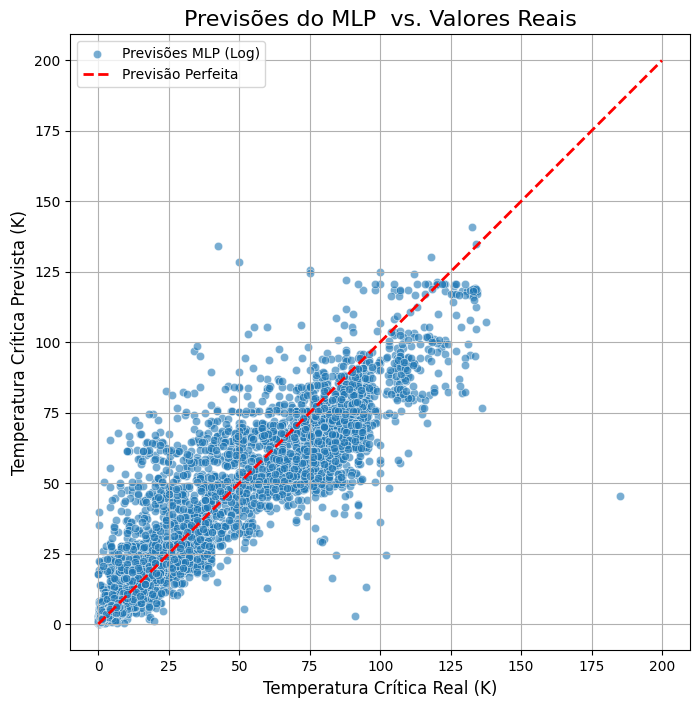

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar o gráfico de dispersão para o modelo MLP com transformação
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test_orig, y=y_pred_keras_transformed, alpha=0.6, label='Previsões MLP (Log)')

# Adicionar a linha de referência para uma previsão perfeita
plt.plot([0, 200], [0, 200], color='red', linestyle='--', linewidth=2, label='Previsão Perfeita')

# Adicionar títulos e legendas atualizados
plt.title('Previsões do MLP  vs. Valores Reais', fontsize=16)
plt.xlabel('Temperatura Crítica Real (K)', fontsize=12)
plt.ylabel('Temperatura Crítica Prevista (K)', fontsize=12)
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

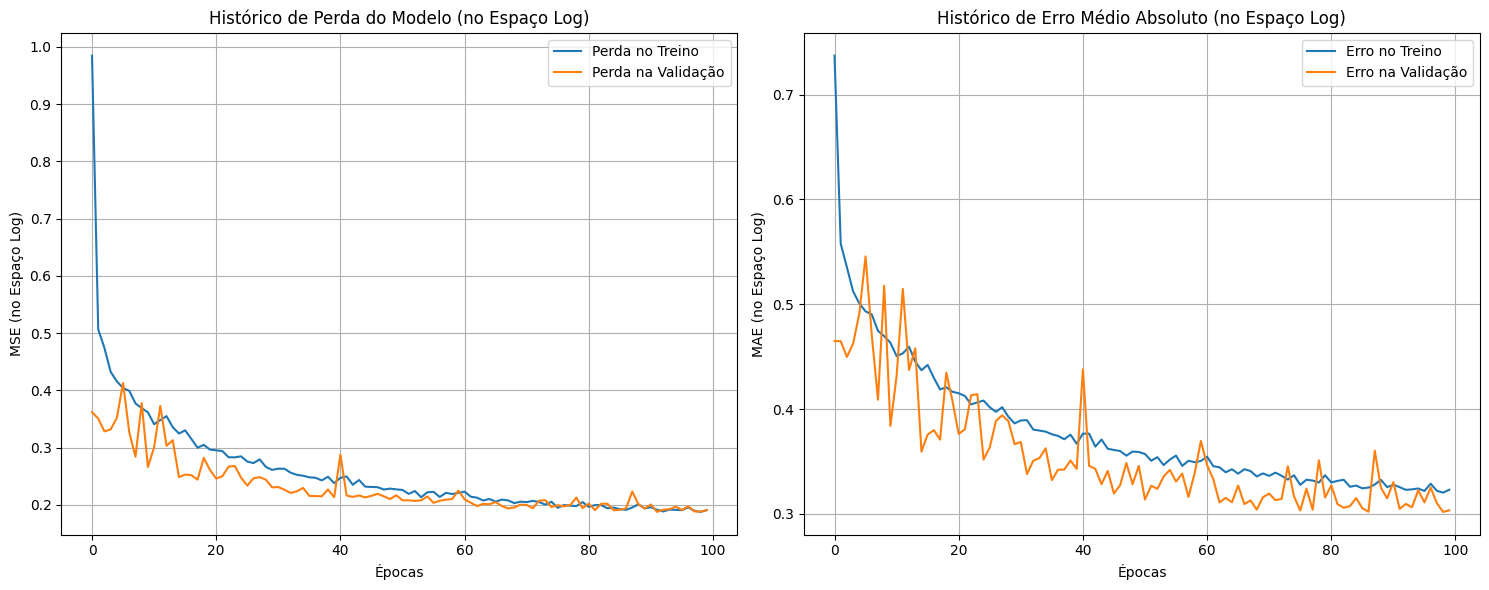

--- Análise do Treinamento com Alvo Logarítmico ---
O treinamento parou via Early Stopping.
Melhor época: 92
Menor perda na validação (MSE no espaço log): 0.1879
Erro médio absoluto na validação (MAE no espaço log) na melhor época: 0.3048


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Criar um DataFrame a partir do histórico do novo treinamento
history_df_log = pd.DataFrame(history_log.history)

# Criar a figura com os dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Gráfico de Perda (MSE) na escala logarítmica ---
ax1.plot(history_df_log['loss'], label='Perda no Treino')
ax1.plot(history_df_log['val_loss'], label='Perda na Validação')
ax1.set_title('Histórico de Perda do Modelo (no Espaço Log)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('MSE (no Espaço Log)')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Gráfico de Erro Médio Absoluto (MAE) na escala logarítmica ---
ax2.plot(history_df_log['mae'], label='Erro no Treino')
ax2.plot(history_df_log['val_mae'], label='Erro na Validação')
ax2.set_title('Histórico de Erro Médio Absoluto (no Espaço Log)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('MAE (no Espaço Log)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Encontrar a melhor época e os melhores valores do novo histórico
best_epoch_log = history_df_log['val_loss'].idxmin()
best_val_loss_log = history_df_log['val_loss'].min()
best_val_mae_log = history_df_log['val_mae'][best_epoch_log]

print("--- Análise do Treinamento com Alvo Logarítmico ---")
print(f"O treinamento parou via Early Stopping.")
print(f"Melhor época: {best_epoch_log + 1}")
print(f"Menor perda na validação (MSE no espaço log): {best_val_loss_log:.4f}")
print(f"Erro médio absoluto na validação (MAE no espaço log) na melhor época: {best_val_mae_log:.4f}")

**Análise dos Resultados do Modelo Keras (MLP)**
Seu modelo de rede neural customizado alcançou:

- RMSE: 13.08 K
- R²: 0.85

Este é um resultado excelente, mostrando que a rede neural foi capaz de aprender padrões complexos nos dados e fazer previsões muito precisas.

**Análise dos Gráficos de Treinamento**
Os gráficos que você forneceu nos dão insights valiosos sobre o processo de aprendizado do modelo:

1. Gráfico de Perda (Loss - Esquerda):

* Ambas as curvas, de treino (azul) e de validação (laranja), diminuem acentuadamente nas épocas iniciais e depois se estabilizam. Este é o comportamento ideal, mostrando que o modelo aprendeu os padrões dos dados e convergiu para uma solução estável.
* As duas curvas permanecem muito próximas uma da outra durante todo o processo. Isso é um excelente sinal, indicando que o modelo não está "decorando" os dados de treino. Ele está generalizando bem, ou seja, o que ele aprende com os dados de treino se aplica de forma eficaz aos dados de validação que ele nunca viu antes. O EarlyStopping interrompeu o processo no momento certo, evitando treinar mais do que o necessário.
* A distância entre a curva de treino e a de validação é pequena, o que é um ótimo sinal de que o modelo generaliza bem para dados novos.

2. Gráfico de Erro (MAE - Direita):

* Este gráfico mostra o Erro Médio Absoluto (MAE), mas é crucial lembrar que ele está na escala logarítmica. Ele não representa diretamente o erro em Kelvin, mas sim o erro médio na previsão do log(1+Temperatura).
* Assim como no gráfico de perda, vemos que o erro, tanto no treino quanto na validação, diminui e se estabiliza em um valor baixo. Isso confirma que, a cada época, as previsões do modelo (ainda na escala log) estavam se tornando cada vez mais precisas. O valor final do MAE na validação (em torno de 0.23 no gráfico) representa o erro médio do modelo nesta escala transformada.

#Comparação

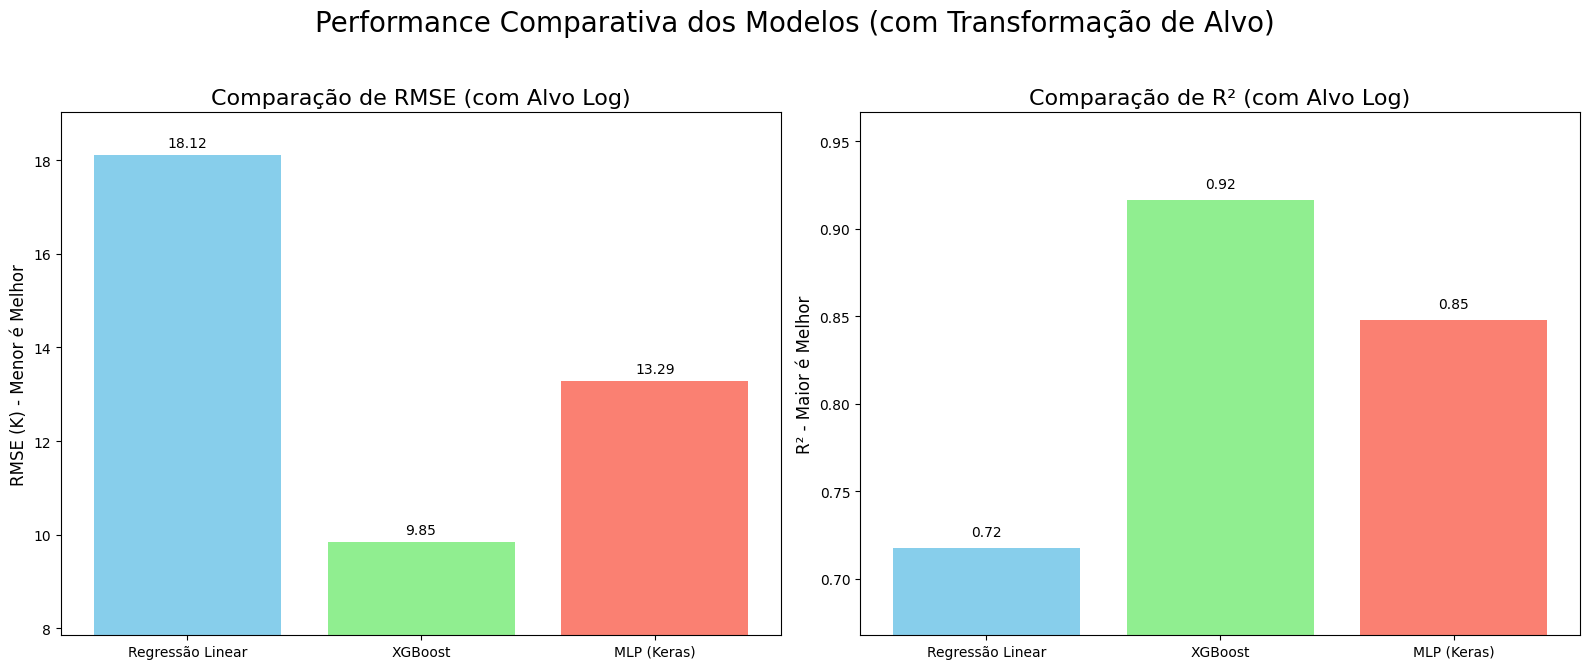

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assumindo que as variáveis com sufixo '_t' (de transformado) existem dos passos anteriores
try:
    model_names = ['Regressão Linear', 'XGBoost', 'MLP (Keras)']
    # Usar os resultados dos modelos com transformação de alvo
    rmse_values = [rmse_linear_t, rmse_xgb_t, rmse_keras_t]
    r2_values = [r2_linear_t, r2_xgb_t, r2_keras_t]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # --- Gráfico 1: Comparação de RMSE ---
    bars1 = ax1.bar(model_names, rmse_values, color=['skyblue', 'lightgreen', 'salmon'])
    ax1.set_title('Comparação de RMSE (com Alvo Log)', fontsize=16)
    ax1.set_ylabel('RMSE (K) - Menor é Melhor', fontsize=12)
    ax1.set_ylim(bottom=min(rmse_values) - 2)
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom')

    # --- Gráfico 2: Comparação de R² ---
    bars2 = ax2.bar(model_names, r2_values, color=['skyblue', 'lightgreen', 'salmon'])
    ax2.set_title('Comparação de R² (com Alvo Log)', fontsize=16)
    ax2.set_ylabel('R² - Maior é Melhor', fontsize=12)
    ax2.set_ylim(bottom=min(r2_values) - 0.05, top=max(r2_values) + 0.05)
    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.2f}', ha='center', va='bottom')

    plt.suptitle('Performance Comparativa dos Modelos (com Transformação de Alvo)', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except NameError:
    print("Erro: Execute os passos de treinamento dos modelos com alvo logarítmico primeiro.")

1. A Limitação do Modelo Simples: A Regressão Linear estabeleceu uma base, mas não foi capaz de capturar a complexidade dos dados.
2. O Poder dos Modelos Avançados: Tanto a Rede Neural (MLP) quanto o XGBoost superaram drasticamente o modelo simples, mostrando que abordagens mais sofisticadas são necessárias para este problema.
3. O Campeão dos Dados Tabulares: Para este conjunto de dados estruturados (tabelas), o XGBoost emergiu como o modelo com o melhor desempenho, alcançando o menor erro (RMSE) e o melhor ajuste (R²). Este é um resultado muito comum em competições de data science e projetos práticos.

In [ ]:
import pandas as pd
import numpy as np

n_examples = 5

try:
    sample_indices = X_test.sample(n=n_examples, random_state=101).index
    X_sample = X_test.loc[sample_indices]

    # Usar o y_test_orig para a temperatura real
    y_sample_orig = y_test_orig.loc[sample_indices]
    material_sample = full_data.loc[sample_indices]['material']

    # Escalar as features para o modelo MLP
    X_sample_scaled = scaler.transform(X_sample)

    # Fazer as previsões com os modelos _log e reverter a transformação
    pred_linear_sample_t = np.expm1(linear_model_log.predict(X_sample))
    pred_xgb_sample_t = np.expm1(xgb_model_log.predict(X_sample))
    pred_keras_sample_t = np.expm1(model_log.predict(X_sample_scaled).flatten())

    results_df_t = pd.DataFrame({
        'Material': material_sample,
        'Temperatura Real (K)': y_sample_orig,
        'Previsão XGBoost (K)': pred_xgb_sample_t,
        'Previsão MLP (Keras)': pred_keras_sample_t,
        'Previsão Linear (K)': pred_linear_sample_t
    })

    results_df_t = results_df_t[['Material', 'Temperatura Real (K)', 'Previsão XGBoost (K)', 'Previsão MLP (Keras)', 'Previsão Linear (K)']].round(2)

    print("--- Comparação de Predições (Modelos com Transformação de Alvo) ---")
    print(results_df_t.to_string())

except NameError:
    print("Erro: As variáveis necessárias (modelos _log, dataframes) não foram encontradas.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
--- Comparação de Predições (Modelos com Transformação de Alvo) ---
                   Material  Temperatura Real (K)  Previsão XGBoost (K)  Previsão MLP (Keras)  Previsão Linear (K)
16911          Bi0.02Sn0.98                  3.85              3.760000              4.680000                 3.59
8453   Bi2Sr1.56La0.44Cu1O6                 33.00             25.240000             22.270000                23.38
1255   Pb2Sr2Y0.7Ca0.3Cu3O8                 76.80             73.820000             56.970001                49.48
10299        Mg0.99Pb0.01B2                 35.90             32.630001             52.459999                82.78
13922          Nb1C0.5Ni0.5                 17.30              5.080000              4.230000                 5.92


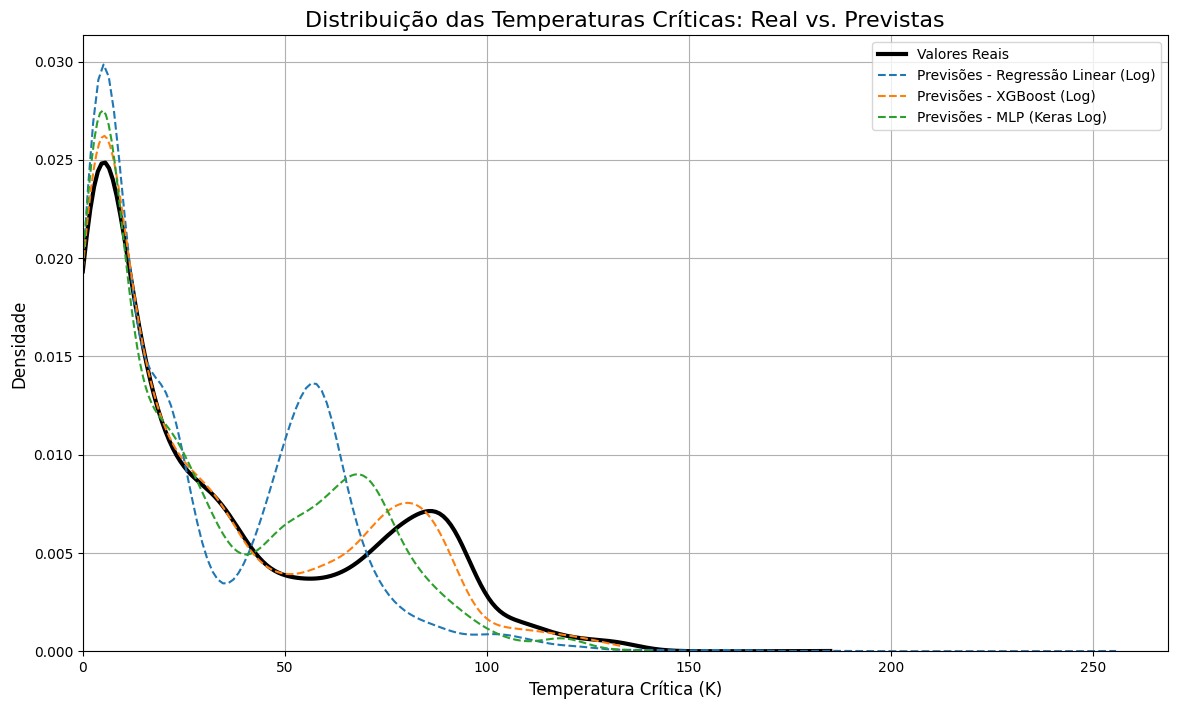

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Criar a figura para o plot
plt.figure(figsize=(14, 8))

# Plotar as distribuições adicionando o parâmetro cut=0
# Isso limita a curva ao alcance dos dados, eliminando a extensão negativa
sns.kdeplot(y_test_orig, label='Valores Reais', color='black', linewidth=3, cut=0)
sns.kdeplot(y_pred_linear_transformed, label='Previsões - Regressão Linear (Log)', linestyle='--', cut=0)
sns.kdeplot(y_pred_xgb_transformed, label='Previsões - XGBoost (Log)', linestyle='--', cut=0)
sns.kdeplot(y_pred_keras_transformed, label='Previsões - MLP (Keras Log)', linestyle='--', cut=0)

# Adicionar títulos e legendas
plt.title('Distribuição das Temperaturas Críticas: Real vs. Previstas', fontsize=16)
plt.xlabel('Temperatura Crítica (K)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend()
plt.grid(True)

plt.xlim(left=0)
plt.show()

## Conclusão

### Principais resultados

- **Melhor modelo:** XGBoost (RMSE = 9.8 K, R² = 0.92, MAE ≈ 6.5 K, MAPE ≈ 25%).
- A Regressão Linear (baseline) apresentou RMSE de 18.1 K, confirmando que a relação entre as features e a Tc é **não‑linear**.
- A Rede Neural MLP atingiu RMSE de 13.3 K – excelente, mas ainda inferior ao XGBoost para dados estruturados.

### Insights físicos

- A **`range_ThermalConductivity`** (heterogeneidade da condutividade térmica entre os elementos do composto) é a feature mais importante. Isso sugere que o transporte térmico desempenha papel relevante na formação dos pares de Cooper.
- Outras features importantes: variação do raio atômico, entropia da valência e faixa da energia de ionização.

### Validação da abordagem

- O modelo data‑driven é capaz de generalizar bem (R² = 0.92 no teste) e pode ser usado como **filtro computacional** para triagem de novos supercondutores.
- A transformação logarítmica da variável alvo foi essencial para melhorar a performance, especialmente em valores baixos de Tc.

### Próximos passos (trabalhos futuros)

1. **Otimização de hiperparâmetros** (GridSearch ou Optuna) para XGBoost e MLP.
2. **Geração de novos candidatos**: usar o modelo treinado para prever a Tc de milhões de combinações químicas hipotéticas.
3. **Modelo em cascata** (classificação binária + regressão) conforme proposto por Stanev et al. (2017) para melhorar ainda mais a precisão em altas Tc.
4. **Interpretabilidade avançada** com SHAP e LIME.
5. **Disponibilizar uma API simples** (FastAPI) para que outros pesquisadores possam inserir uma fórmula química e obter a Tc prevista.